# Sales Forecasting: A Time Series Machine Learning Approach

## 1. Project Introduction

**Goal:** Forecast future sales based on historical patterns to support inventory planning and strategic decision-making.

**Dataset:** Custom sales dataset with daily/monthly transaction records.

**Tools:** Python, Prophet, ARIMA, LSTM, Scikit-learn, Pandas, Matplotlib, Statsmodels

The notebook includes:

- 📊 Exploratory Data Analysis (EDA)
- 🧹 Data Preprocessing & Time Series Cleaning
- 🏗️ Model Building (Prophet, ARIMA, LSTM)
- 🎯 Model Evaluation & Cross-Validation
- 📉 Forecast Visualization & Comparison




2: Import Libraries & Set Configurations

In [ ]:
# ✅ Just Prophet — works well in Colab
!pip install prophet --quiet
!pip install --upgrade numpy


# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Forecasting
from prophet import Prophet
from statsmodels.tsa.seasonal import STL
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# Plotting & Warnings
import warnings
warnings.filterwarnings('ignore')
sns.set(rc={"figure.figsize": (14, 5)})


In [ ]:
# Upload file manually
from google.colab import files
uploaded = files.upload()


Saving data.csv to data (2).csv


In [ ]:
#Read the uploaded CSV file
import pandas as pd

df = pd.read_csv('data.csv', encoding='ISO-8859-1')

#Convert datetime, calculate sales
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Sales'] = df['Quantity'] * df['UnitPrice']
df = df[df['Sales'] > 0]

#Create 'Date' column and aggregate by day
df['Date'] = df['InvoiceDate'].dt.date
daily_sales = df.groupby('Date')['Sales'].sum().reset_index()
daily_sales['Date'] = pd.to_datetime(daily_sales['Date'])
daily_sales.set_index('Date', inplace=True)
daily_sales = daily_sales.asfreq('D', fill_value=0)

# Preview
daily_sales.head()


,Sales
Date,
2010-12-01,58960.79
2010-12-02,47748.38
2010-12-03,46943.71
2010-12-04,0.00
2010-12-05,31774.95


3. EDA & STL Decomposition

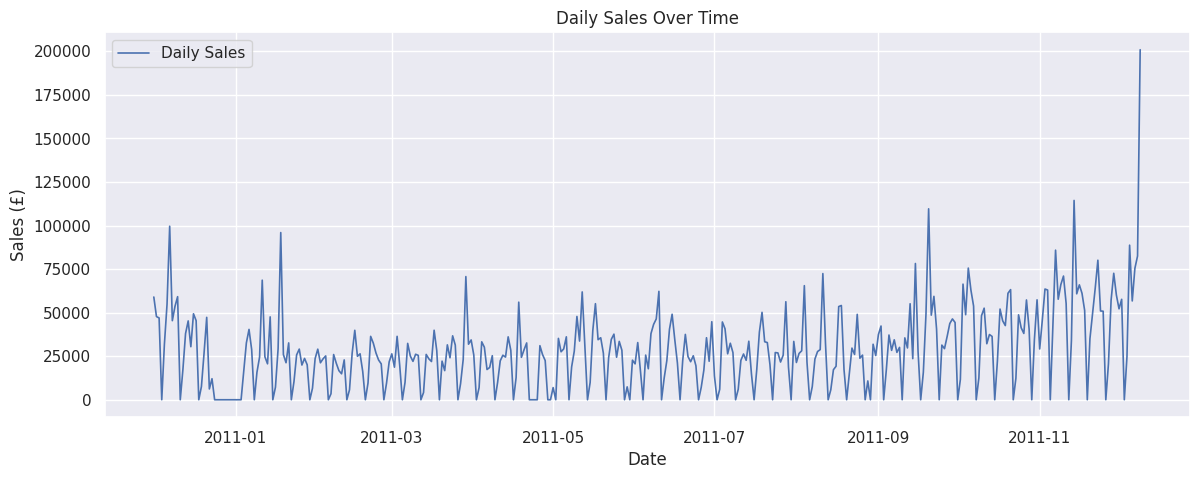

In [ ]:
#Daily Sales Over Time
plt.figure(figsize=(14,5))
plt.plot(daily_sales.index, daily_sales['Sales'], label='Daily Sales', linewidth=1.2)
plt.title("Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.legend()
plt.show()


# Daily Sales Over Time

# This plot visualizes the daily sales trend throughout the dataset.
# It helps identify seasonal patterns, sales volatility, and any spikes or anomalies.

# - The x-axis shows the date range.
# - The y-axis displays the daily sales values.
# - Peaks may indicate promotions, holidays, or unusual customer demand.
# - Grid lines and legends are added for clarity.

# This time-series visualization lays the groundwork for further decomposition and forecasting.

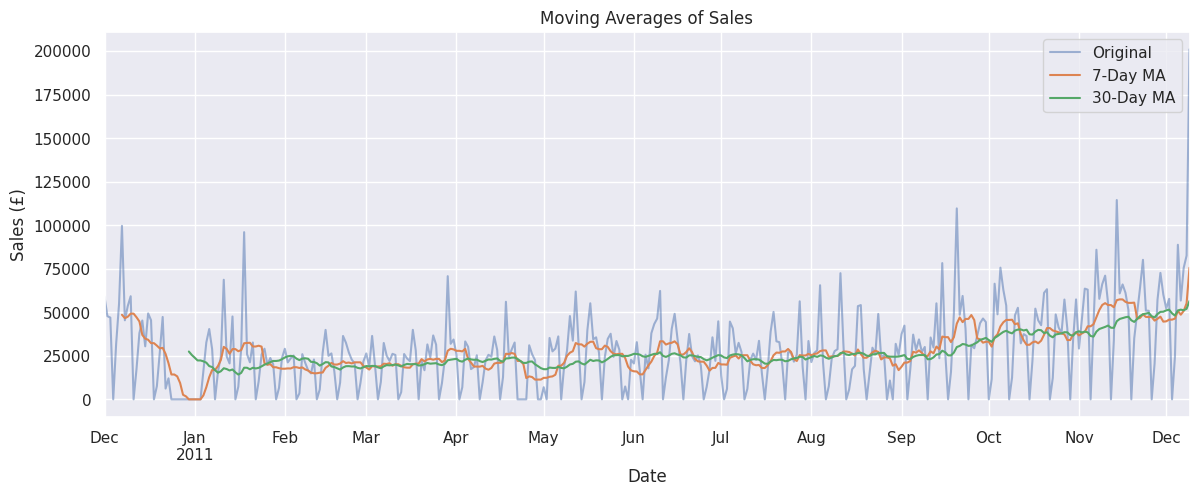

In [ ]:
#7-day & 30-day Rolling Mean
plt.figure(figsize=(14,5))
daily_sales['Sales'].plot(label='Original', alpha=0.5)
daily_sales['Sales'].rolling(7).mean().plot(label='7-Day MA')
daily_sales['Sales'].rolling(30).mean().plot(label='30-Day MA')
plt.title("Moving Averages of Sales")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(True)
plt.show()


# This plot applies rolling (moving) averages to smooth out short-term fluctuations and highlight longer-term trends in sales data.

# - The original line shows raw daily sales (no smoothing).
# - The 7-day moving average smooths over one week, capturing weekly trends.
# - The 30-day moving average smooths over a month, revealing broader seasonal trends.

# These moving averages help in identifying consistent upward or downward trends and are valuable in time series forecasting.

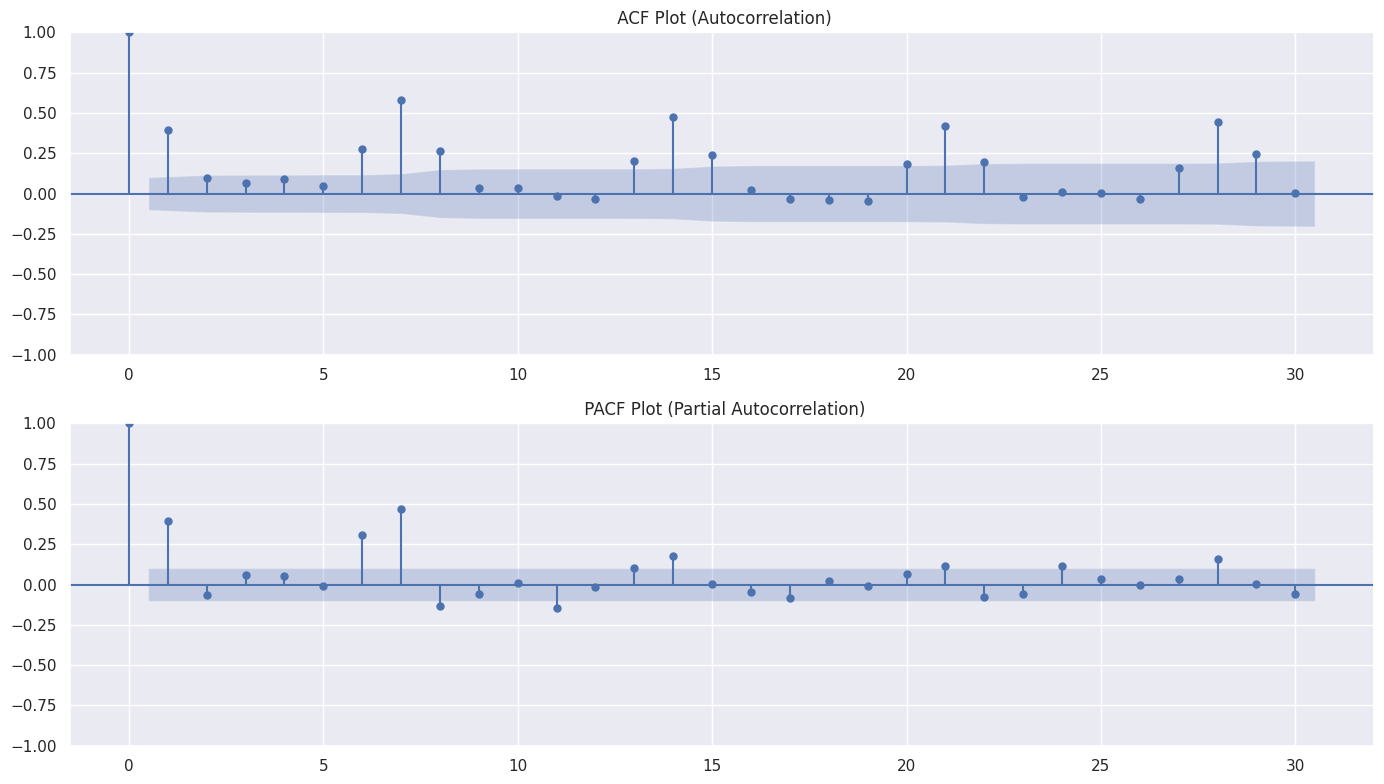

In [ ]:
#ACF and PACF (Autocorrelation Analysis)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, ax = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(daily_sales['Sales'], lags=30, ax=ax[0])
plot_pacf(daily_sales['Sales'], lags=30, ax=ax[1])
ax[0].set_title(' ACF Plot (Autocorrelation)')
ax[1].set_title(' PACF Plot (Partial Autocorrelation)')
plt.tight_layout()
plt.show()

#These plots help determine the order of ARIMA models by analyzing how strongly  current sales are correlated with past values (lags).

# ACF (Autocorrelation Function)
# - Measures the correlation between the time series and its lagged versions.
# - Useful for identifying the MA (Moving Average) component of ARIMA models.

#  PACF (Partial Autocorrelation Function)
# - Measures the correlation between the series and its lag, after removing the effect of intermediate lags.
# - Helps identify the AR (AutoRegressive) component of ARIMA models.

# Spikes outside the confidence interval (shaded area) indicate significant lags.


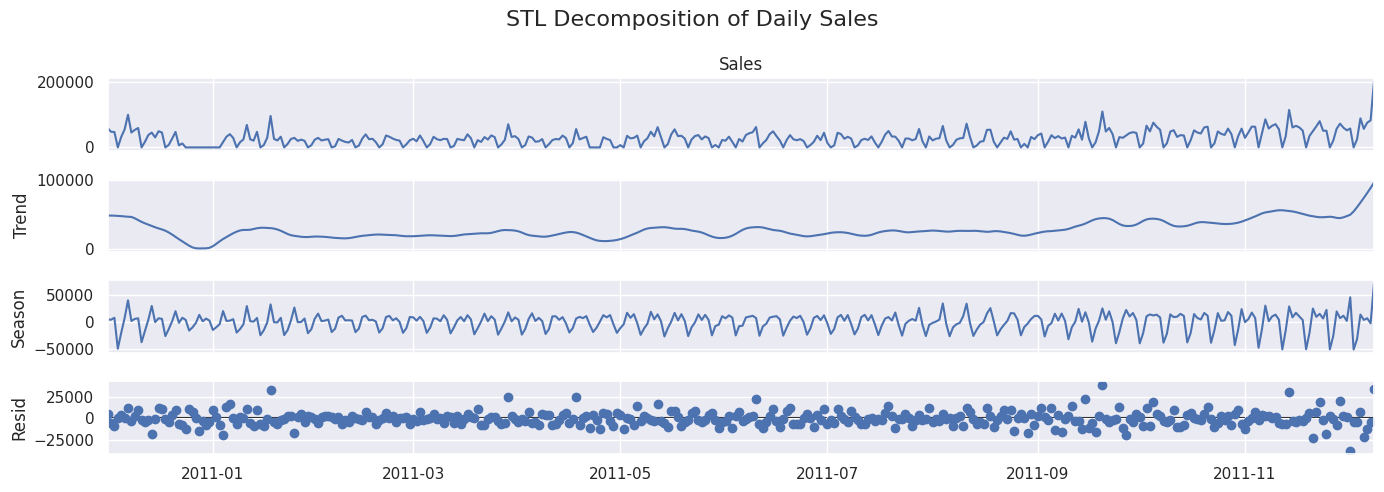

In [ ]:
from statsmodels.tsa.seasonal import STL

# STL Decomposition (weekly seasonality → period=7)
stl = STL(daily_sales['Sales'], period=7)
result = stl.fit()

# Plot trend, seasonality, and residuals
result.plot()
plt.suptitle("STL Decomposition of Daily Sales", fontsize=16)
plt.tight_layout()
plt.show()




# STL breaks down a time series into three components:
# 1. Trend – the long-term progression in the data
# 2. Seasonal – repeated short-term cycles
# 3. Residual – irregular fluctuations or noise that cannot be explained by trend or seasonality

# We use a seasonal period of 7 to reflect weekly seasonality.

In [ ]:
#Detect Anomalies

# Re-run STL to get access to residuals
from statsmodels.tsa.seasonal import STL

stl = STL(daily_sales['Sales'], period=7)
res = stl.fit()

# Get residuals
residuals = res.resid
std = residuals.std()

# Define anomaly threshold
threshold = 3 * std

# Tag anomalies
anomalies = (abs(residuals) > threshold)

# Add back to DataFrame
daily_sales_clean = daily_sales.copy()
daily_sales_clean['Anomaly'] = anomalies
daily_sales_clean['Residual'] = residuals


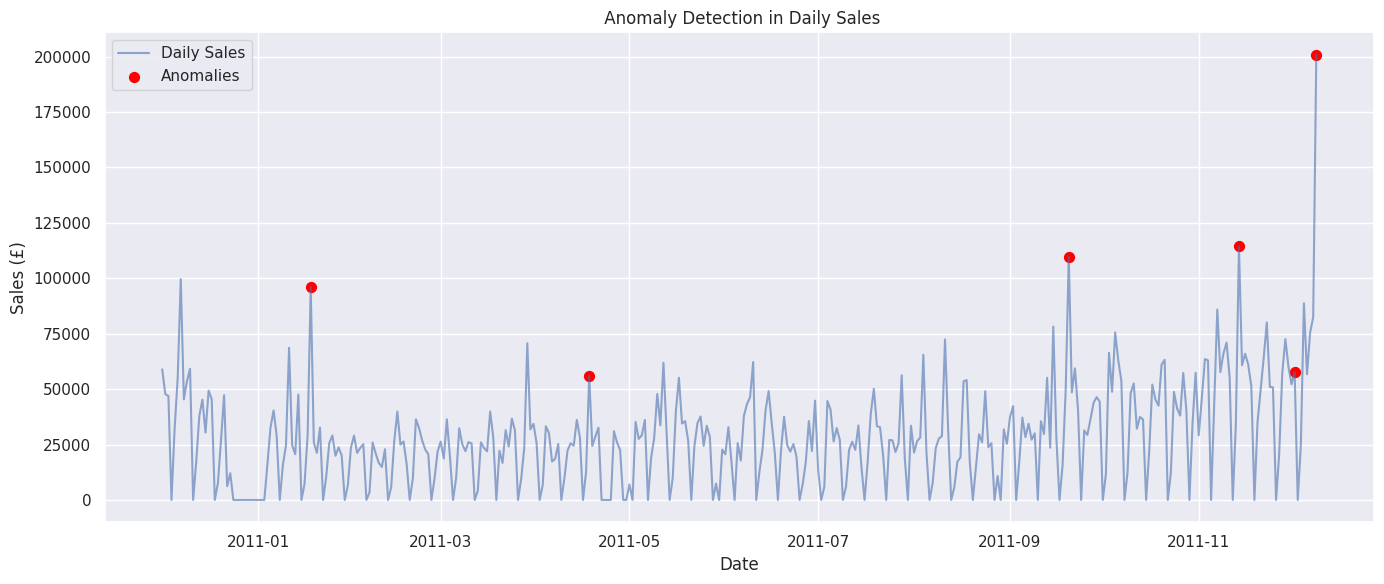

In [ ]:
#Visualize Anomalies
plt.figure(figsize=(14,6))
plt.plot(daily_sales_clean.index, daily_sales_clean['Sales'], label='Daily Sales', alpha=0.6)
plt.scatter(
    daily_sales_clean[daily_sales_clean['Anomaly']].index,
    daily_sales_clean[daily_sales_clean['Anomaly']]['Sales'],
    color='red', label='Anomalies', s=50
)
plt.title(" Anomaly Detection in Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# This plot highlights outlier points (anomalies) in the daily sales data.
# Anomalies are data points that deviate significantly from the trend or pattern and may indicate special events, errors, or rare occurrences.

# - The blue line shows the regular daily sales over time.
# - Red dots represent identified anomalies.
# - These anomalies were previously marked in a new 'Anomaly' column in the cleaned dataset.


3. Modelling

Linear Regression



In [ ]:
# Drop anomalies to get cleaner signal for modeling
daily_sales_forecast = daily_sales_clean[~daily_sales_clean['Anomaly']]['Sales']


In [ ]:
#Baseline Forecast with Linear Regression

# Prepare lag features from cleaned data
df_lr = pd.DataFrame(daily_sales_forecast).copy()
df_lr = df_lr.rename(columns={'Sales': 'y'})

# Add lag features for previous 7 days
for lag in range(1, 8):
    df_lr[f'lag_{lag}'] = df_lr['y'].shift(lag)

# Drop initial rows with NaN from lagging
df_lr = df_lr.dropna()



In [ ]:
# 80/20 split based on index
split_index = int(len(df_lr) * 0.8)
train = df_lr.iloc[:split_index]
test = df_lr.iloc[split_index:]

X_train = train.drop(columns='y')
y_train = train['y']
X_test = test.drop(columns='y')
y_test = test['y']


In [ ]:
#Train Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Train model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predict
y_pred = lr_model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Linear Regression Results (80/20 Split):")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")


Linear Regression Results (80/20 Split):
RMSE: 19844.86
MAE: 15573.15


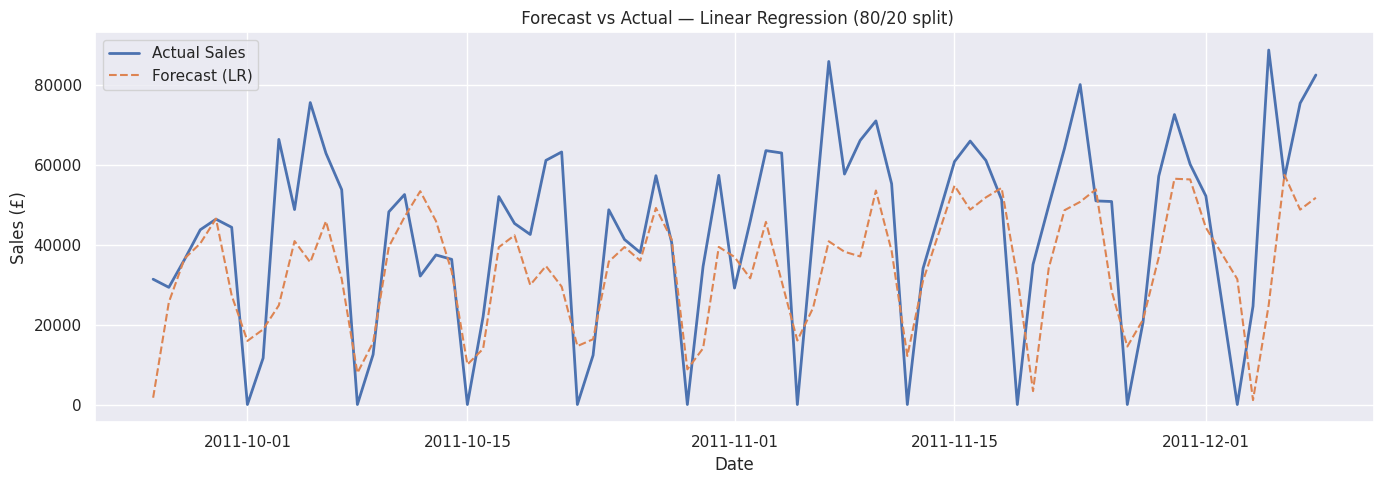

In [ ]:
#Plotting Forecast vs Actual
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test.index, y_test, label='Actual Sales', linewidth=2)
plt.plot(y_test.index, y_pred, label='Forecast (LR)', linestyle='--')
plt.title(" Forecast vs Actual — Linear Regression (80/20 split)")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Prohet Model

In [ ]:
#Forecasting with Prophet

from prophet import Prophet

# Prepare dataframe
df_prophet = daily_sales_forecast.reset_index().rename(columns={'Date': 'ds', 'Sales': 'y'})



In [ ]:
#Train the Prophet Model

# Initialize model
model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Fit model
model.fit(df_prophet)


DEBUG:cmdstanpy:input tempfile: /tmp/tmpohypak8j/9mz5d_fy.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpohypak8j/7vsr0rmm.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=22260', 'data', 'file=/tmp/tmpohypak8j/9mz5d_fy.json', 'init=/tmp/tmpohypak8j/7vsr0rmm.json', 'output', 'file=/tmp/tmpohypak8j/prophet_model0ib04ii8/prophet_model-20250617014952.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:49:52 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:49:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


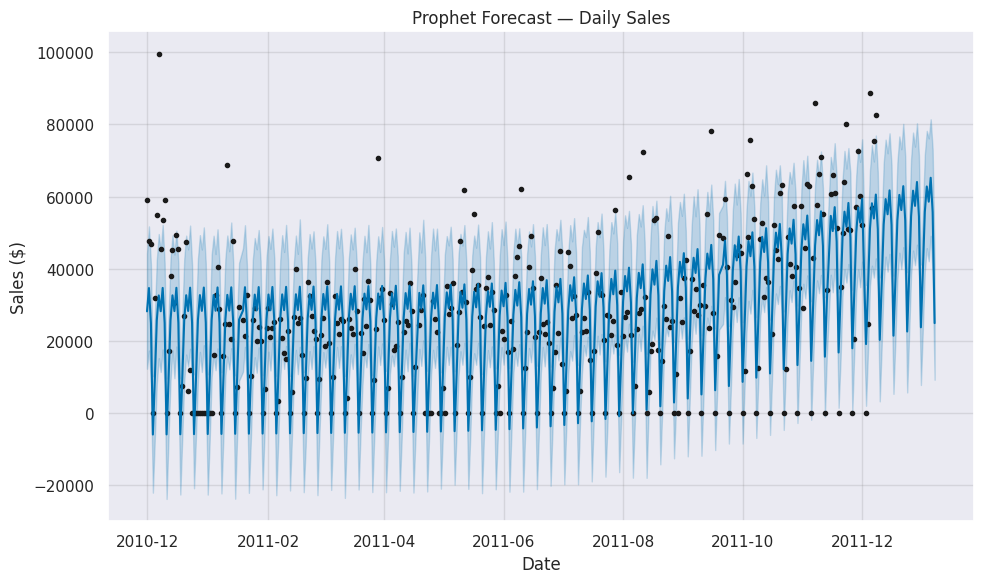

In [68]:
#Future 30 Days Prediction

# Create future dataframe
future = model.make_future_dataframe(periods=30)

# Forecast
forecast = model.predict(future)

# Forecast plot
model.plot(forecast)
plt.title("Prophet Forecast — Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()


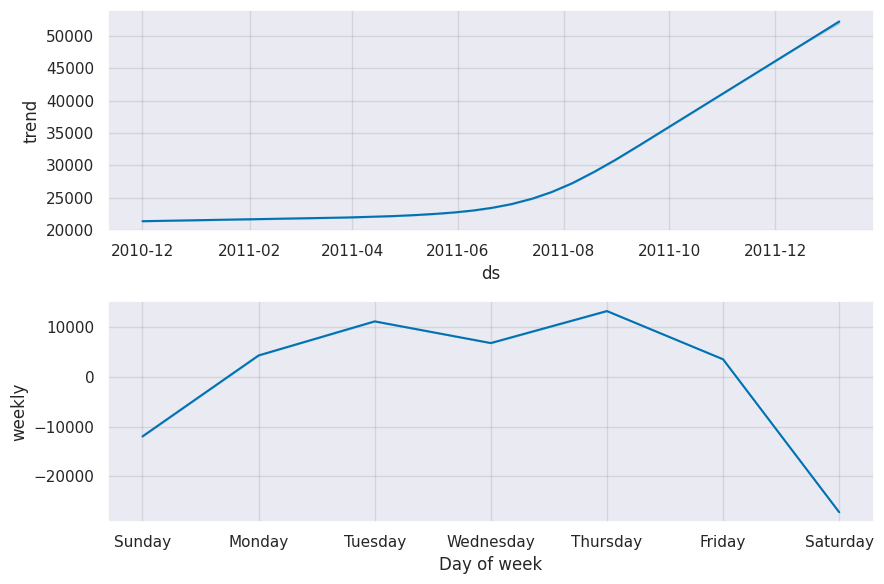

In [69]:
#plot trend and seasonality

model.plot_components(forecast)
plt.tight_layout()
plt.show()


In [70]:
#tune prophet parameters

# Tuned Prophet Model
tuned_model = Prophet(
    changepoint_prior_scale=0.05,  # adjust sensitivity to trend changes
    seasonality_prior_scale=10.0,  # adjust seasonality flexibility
    weekly_seasonality=True,
    yearly_seasonality=False,
    daily_seasonality=False
)

# Add custom monthly seasonality
tuned_model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

# Fit model
tuned_model.fit(df_prophet)


DEBUG:cmdstanpy:input tempfile: /tmp/tmpohypak8j/gjftnnu6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpohypak8j/sbhvd0bg.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=11648', 'data', 'file=/tmp/tmpohypak8j/gjftnnu6.json', 'init=/tmp/tmpohypak8j/sbhvd0bg.json', 'output', 'file=/tmp/tmpohypak8j/prophet_model9t2iuxor/prophet_model-20250617015717.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:57:18 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:57:18 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [71]:
#Forecast 30 days again

# Future dataframe
future = tuned_model.make_future_dataframe(periods=30)

# Generate forecast
forecast = tuned_model.predict(future)


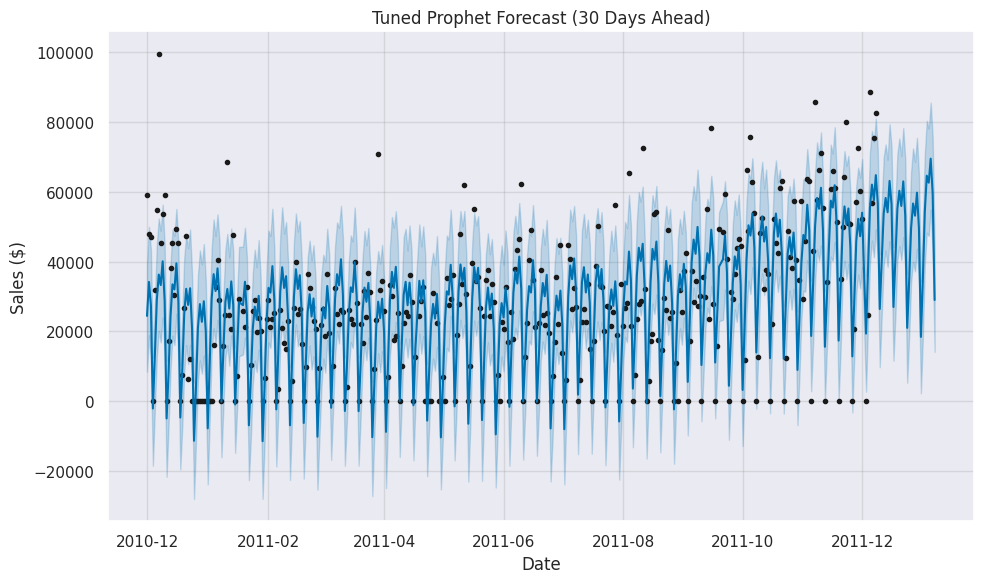

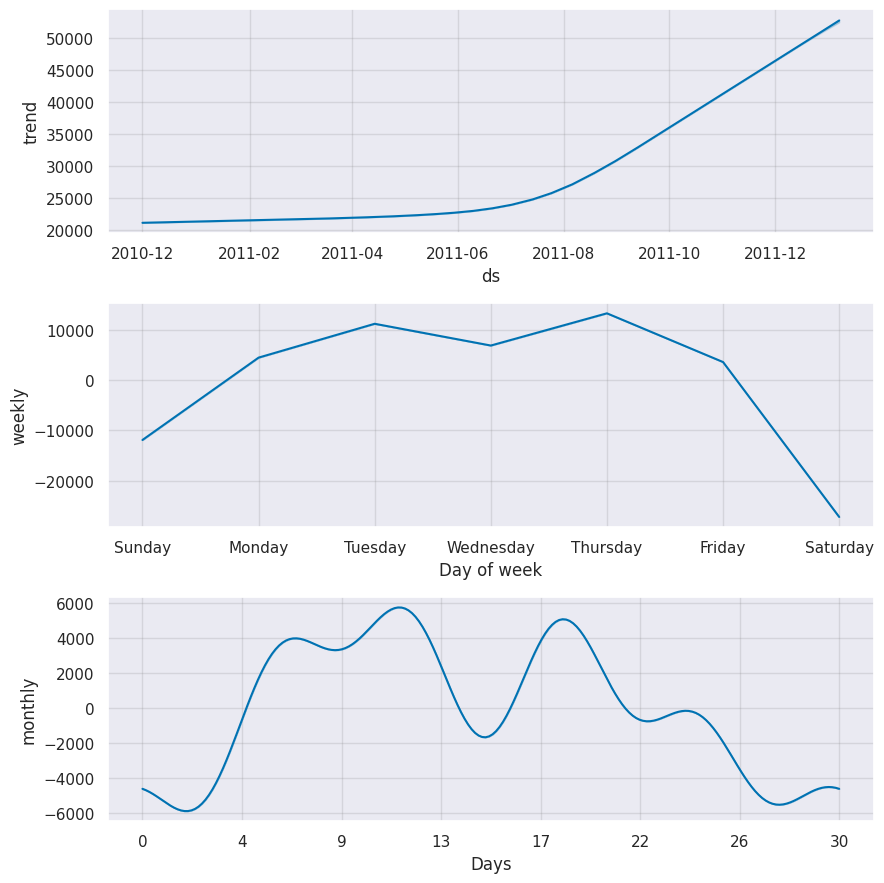

In [72]:
# Visualize the Tuned Forecast

# Plot forecast
tuned_model.plot(forecast)
plt.title("Tuned Prophet Forecast (30 Days Ahead)")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()

# Component plots
tuned_model.plot_components(forecast)
plt.tight_layout()
plt.show()


In [73]:
#Evaluate Prophet Forecast Accuracy (On Same Test Set)

# Extract actuals from last known values
actual = df_prophet.set_index('ds').loc[y_test.index]['y']

# Extract Prophet prediction for those same dates
forecast.set_index('ds', inplace=True)
prophet_pred = forecast.loc[y_test.index]['yhat']

# Evaluate
prophet_rmse = np.sqrt(mean_squared_error(actual, prophet_pred))
prophet_mae = mean_absolute_error(actual, prophet_pred)

print("Tuned Prophet Model Results:")
print(f"RMSE: {prophet_rmse:.2f}")
print(f"MAE: {prophet_mae:.2f}")


Tuned Prophet Model Results:
RMSE: 13046.08
MAE: 10445.96


In [74]:
print("\n Model Comparison:")
print(f"Linear Regression → RMSE: {rmse:.2f} | MAE: {mae:.2f}")
print(f"Prophet           → RMSE: {prophet_rmse:.2f} | MAE: {prophet_mae:.2f}")



 Model Comparison:
Linear Regression → RMSE: 19844.86 | MAE: 15573.15
Prophet           → RMSE: 13046.08 | MAE: 10445.96


In [75]:
#Prophet Cross-Validation
from prophet.diagnostics import cross_validation, performance_metrics


In [76]:
#Cross-Validate with Rolling Forecast Origin
from prophet.diagnostics import cross_validation

df_cv = cross_validation(
    model=tuned_model,
    initial='300 days',     # shorter initial training window
    period='30 days',       # how often to re-evaluate
    horizon='30 days',      # forecast period for evaluation
    parallel="processes"
)


INFO:prophet:Making 2 forecasts with cutoffs between 2011-10-09 00:00:00 and 2011-11-08 00:00:00
INFO:prophet:Applying in parallel with <concurrent.futures.process.ProcessPoolExecutor object at 0x7883d7e92bd0>
DEBUG:cmdstanpy:input tempfile: /tmp/tmpohypak8j/50v8hff1.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpohypak8j/x7ar891q.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpohypak8j/pe8jn0kb.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpohypak8j/3tjkmzb0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=21278', 'data', 'file=/tmp/tmpohypak8j/50v8hff1.json', 'init=/tmp/tmpohypak8j/pe8jn0kb.json', 'output', 'file=/tmp/tmpohypak8j/prophet_model3saiwzp8/prophet_model-20250617015719.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
DEBUG:cmdstanpy:CmdStan args:

In [77]:
#Evaluate with Performance Metrics
from prophet.diagnostics import performance_metrics
df_p_metrics = performance_metrics(df_cv)
df_p_metrics.describe()


INFO:prophet:Skipping MAPE because y close to 0


,horizon,mse,rmse,mae,mdape,smape,coverage
count,28,2.800000e+01,28.000000,28.000000,28.000000,28.000000,28.000000
mean,16 days 12:00:00,2.534443e+08,14792.535310,12517.078061,0.268841,0.536143,0.667857
std,8 days 05:25:24.250324976,2.074223e+08,5992.299817,5083.520947,0.113526,0.217330,0.243514
min,3 days 00:00:00,3.948141e+07,6283.423158,5387.060820,0.068843,0.107284,0.100000
25%,9 days 18:00:00,1.077635e+08,10380.434191,8529.251503,0.194704,0.406192,0.500000
50%,16 days 12:00:00,1.660661e+08,12871.039035,10496.895311,0.263102,0.556315,0.650000
75%,23 days 06:00:00,3.486419e+08,18668.459446,15129.943807,0.356275,0.660194,0.825000
max,30 days 00:00:00,8.444141e+08,29058.803789,23731.796558,0.456622,0.896409,1.000000


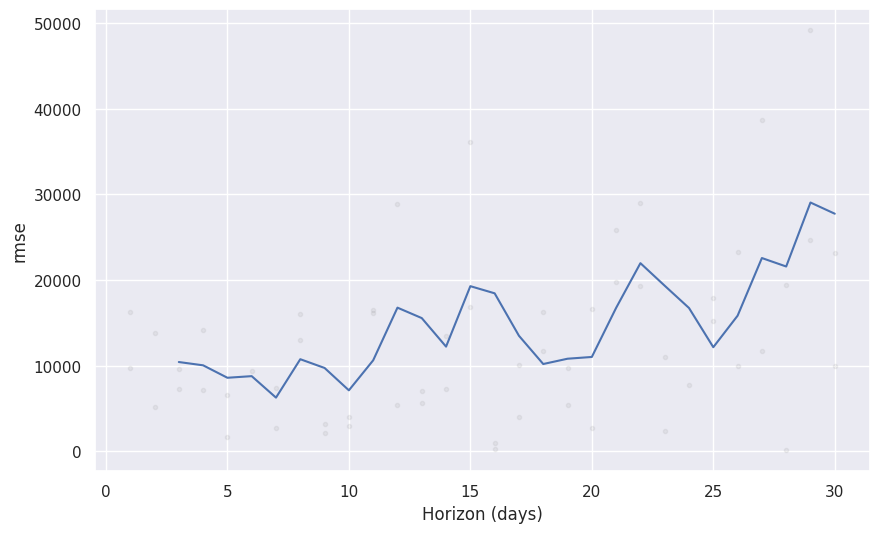

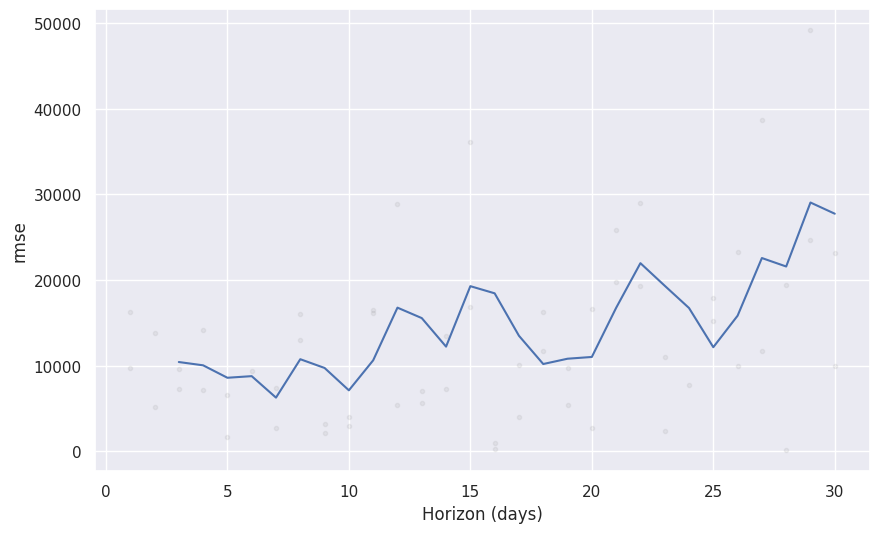

In [78]:
#Visualize Forecast Accuracy
from prophet.plot import plot_cross_validation_metric

plot_cross_validation_metric(df_cv, metric='rmse')


LSTM

In [79]:
#Prepare Sliding Windows for LSTM
import numpy as np

# Use cleaned data
values = daily_sales_forecast.values

# Define lookback
lookback = 14
X_lstm, y_lstm = [], []

for i in range(lookback, len(values)):
    X_lstm.append(values[i-lookback:i])
    y_lstm.append(values[i])

X_lstm, y_lstm = np.array(X_lstm), np.array(y_lstm)

# Reshape for LSTM [samples, timesteps, features]
X_lstm = X_lstm.reshape((X_lstm.shape[0], X_lstm.shape[1], 1))


In [80]:
split = int(len(X_lstm) * 0.8)

X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]


In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model_lstm = Sequential([
    LSTM(50, activation='relu', input_shape=(lookback, 1)),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train_lstm, y_train_lstm, epochs=20, verbose=1)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 738943616.0000
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 815337920.0000
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 802144896.0000
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 673523392.0000
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 744395968.0000
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 875957248.0000
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 629084864.0000
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 574742592.0000
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 518648800.0000
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 385948224.0000
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 314575680.0000
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 372184256.0000
Epoch 13/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 343251456.0000
Epoch 14/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 357

In [82]:
y_pred_lstm = model_lstm.predict(X_test_lstm)

# Evaluation
lstm_rmse = np.sqrt(mean_squared_error(y_test_lstm, y_pred_lstm))
lstm_mae = mean_absolute_error(y_test_lstm, y_pred_lstm)

print(" LSTM Results:")
print(f"RMSE: {lstm_rmse:.2f}")
print(f"MAE: {lstm_mae:.2f}")


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
 LSTM Results:
RMSE: 23528.92
MAE: 17292.74


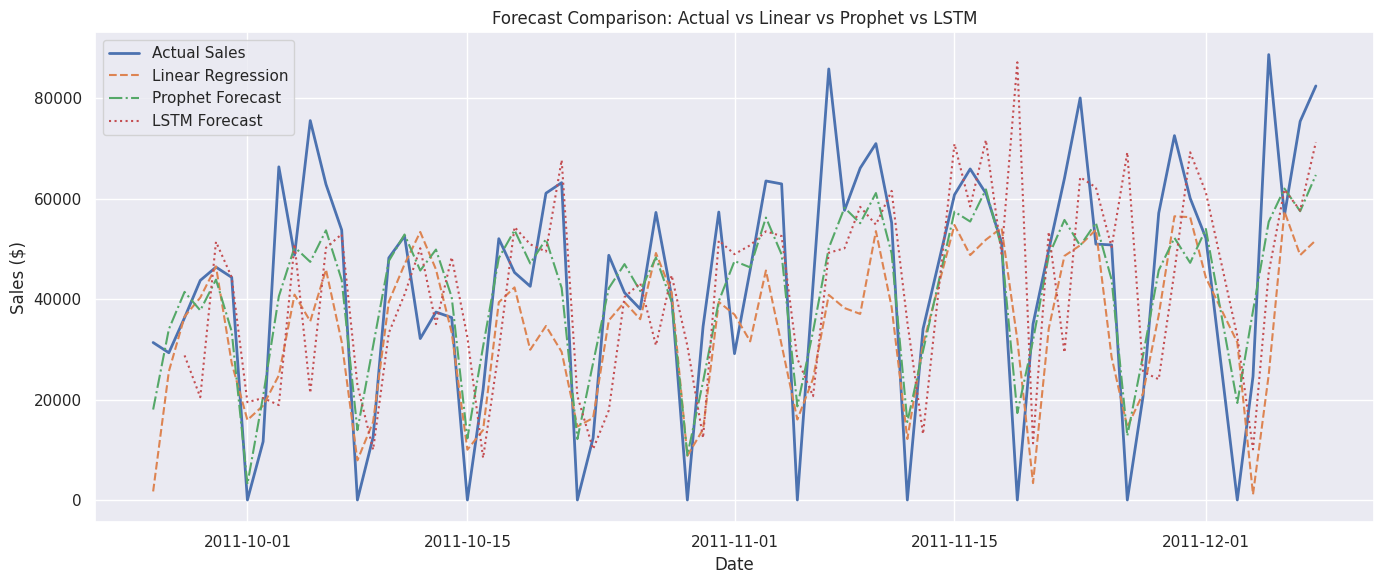

In [83]:
# Regenerate future dataframe and forecast

future = tuned_model.make_future_dataframe(periods=30)
forecast = tuned_model.predict(future)

# Align Prophet forecast with test period
prophet_pred_aligned = forecast.set_index('ds').loc[y_test.index]['yhat']

# Align LSTM predictions
lstm_dates = y_test.index[-len(y_pred_lstm):]
lstm_preds_series = pd.Series(y_pred_lstm.flatten(), index=lstm_dates)

# Align Linear Regression predictions
lr_preds_series = pd.Series(y_pred, index=y_test.index)

# Plot Actual vs Forecasts
plt.figure(figsize=(14,6))
plt.plot(y_test.index, y_test, label='Actual Sales', linewidth=2)
plt.plot(lr_preds_series.index, lr_preds_series, label='Linear Regression', linestyle='--')
plt.plot(prophet_pred_aligned.index, prophet_pred_aligned, label='Prophet Forecast', linestyle='-.')
plt.plot(lstm_preds_series.index, lstm_preds_series, label='LSTM Forecast', linestyle=':')
plt.title("Forecast Comparison: Actual vs Linear vs Prophet vs LSTM")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()




*   Prophet tracks general seasonality and trends very well
*   Linear Regression lags behind and misses large spikes
*   LSTM is more sensitive to volatility, sometimes overshooting








